In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read csv
df = pd.read_csv("car_fuel_efficiency_2026.csv")

In [3]:
cols = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

In [4]:
for col in df.columns:
    if col not in cols:
        del df[col]

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

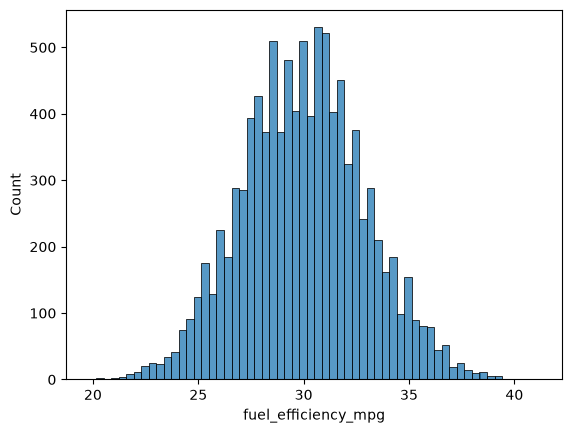

In [5]:
sns.histplot(df['fuel_efficiency_mpg'])

In [6]:
# Question 1 
# There's one column with missing values. What is it?

df.isnull().sum()

model_year               0
engine_displacement      0
horsepower             877
vehicle_weight           0
fuel_efficiency_mpg      0
dtype: int64

In [7]:
# Question 2
# What's the median (50% percentile) for variable 'horsepower'?

df['horsepower'].median()

np.float64(254.0)

In [8]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [9]:
y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [10]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [11]:
# Q3: compare missing-value imputation strategies
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
horsepower_mean = df_train['horsepower'].mean()

X_train_zero = df_train[base].fillna(0).values
X_val_zero = df_val[base].fillna(0).values
X_train_mean = df_train[base].fillna(horsepower_mean).values
X_val_mean = df_val[base].fillna(horsepower_mean).values

b0, w0 = train_linear_regression(X_train_zero, y_train)
b_mean, w_mean = train_linear_regression(X_train_mean, y_train)

y_pred_zero = b0 + X_val_zero.dot(w0)
y_pred_mean = b_mean + X_val_mean.dot(w_mean)

rmse_zero = round(np.sqrt(np.mean((y_val - y_pred_zero) ** 2)), 3)
rmse_mean = round(np.sqrt(np.mean((y_val - y_pred_mean) ** 2)), 3)

print(f'Zero fill RMSE: {rmse_zero}')
print(f'Mean fill RMSE: {rmse_mean}')
print(f'Better option: {"mean" if rmse_mean < rmse_zero else "zero"}')

Zero fill RMSE: 2.205
Mean fill RMSE: 2.202
Better option: mean


In [ ]:
# Question 4
# Now let's train a regularized linear regression.
# For this question, fill the NAs with 0.
# Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
# Use RMSE to evaluate the model on the validation dataset.
# Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
# Which r gives the best RMSE?
# If multiple options give the same best RMSE, select the smallest r.

In [14]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
X_train = df_train[base].fillna(0).values
X_val = df_val[base].fillna(0).values


def train_linear_regression_regularized(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_scores = {}

for r in r_values:
    b, w = train_linear_regression_regularized(X_train, y_train, r)
    y_pred = b + X_val.dot(w)
    score = round(np.sqrt(np.mean((y_val - y_pred) ** 2)), 4)
    rmse_scores[r] = score
    print(f'r = {r}: {score}')

best_r = min(r_values, key=lambda r: (rmse_scores[r], r))
print(f'Best r: {best_r}')
print(f'Best RMSE: {rmse_scores[best_r]}')


r = 0: 2.2053
r = 0.01: 2.2058
r = 0.1: 2.2241
r = 1: 2.3492
r = 5: 2.4094
r = 10: 2.4195
r = 100: 2.4292
Best r: 0
Best RMSE: 2.2053


In [16]:
# Question 5
# We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
# Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
# For each seed, do the train/validation/test split with 60%/20%/20% distribution.
# Fill the missing values with 0 and train a model without regularization.
# For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
# What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
# Round the result to 3 decimal digits (round(std, 3))

In [17]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
scores = []

for seed in range(10):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
    df_test = df.iloc[idx[n_train + n_val:]].copy()

    y_train = df_train['fuel_efficiency_mpg']
    y_val = df_val['fuel_efficiency_mpg']
    y_test = df_test['fuel_efficiency_mpg']

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = df_train[base].fillna(0).values
    X_val = df_val[base].fillna(0).values

    b, w = train_linear_regression(X_train, y_train)
    y_pred = b + X_val.dot(w)
    score = np.sqrt(np.mean((y_val - y_pred) ** 2))
    scores.append(score)

std = round(np.std(scores), 3)
print(f'Scores: {scores}')
print(f'Std: {std}')


Scores: [np.float64(2.2392041430461465), np.float64(2.2021128210838907), np.float64(2.163419778753095), np.float64(2.2043588768539144), np.float64(2.2018800943312926), np.float64(2.2457851509084974), np.float64(2.269721207952404), np.float64(2.190794599933433), np.float64(2.2166112016864443), np.float64(2.207036592817851)]
Std: 0.029


In [18]:
# Question 6
# Split the dataset like previously, use seed 9.
# Combine train and validation datasets.
# Fill the missing values with 0 and train a model with r=0.001.
# What's the RMSE on the test dataset?

In [19]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

n = len(df)
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

combined = pd.concat([df_train, df_val], axis=0)

y_train = combined['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

X_train = combined[base].fillna(0).values
X_test = df_test[base].fillna(0).values

X = np.column_stack([np.ones(X_train.shape[0]), X_train])
XTX = X.T.dot(X)
XTX = XTX + 0.001 * np.eye(XTX.shape[0])
XTX[0, 0] = 0

w = np.linalg.inv(XTX) @ X.T @ y_train.values
y_pred = np.column_stack([np.ones(X_test.shape[0]), X_test]) @ w
rmse = round(np.sqrt(np.mean((y_test.values - y_pred) ** 2)), 6)
print(f'Test RMSE: {rmse}')


Test RMSE: 2.472039
